# Notebook 2 - Data Pre-Processing

## Environment Setup and Configuration

This section prepares the environment required for preprocessing and dataset preparation. Core libraries for data handling, visualisation, and utility operations are imported to support the pipeline.

Project-specific parameters are accessed through a central configuration module to maintain consistency across notebooks. This ensures that file paths, label mappings, and preprocessing settings remain aligned.

A dedicated directory is also prepared to store preprocessing outputs, allowing intermediate results and visualisations to be organised systematically.

In [1]:
# System path configured for project-level imports
import sys, os, re, pickle
sys.path.insert(0, os.path.abspath('..'))

# Core libraries for data handling and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter

# Warnings suppressed for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Project configuration parameters and paths
from config import (
    RAW_CSV,
    VISUALISATION_DIR,
    LABELLED_DATASET,
    LABEL2ID,
    NEGATION_CUES,
    NEGATION_WINDOW,
    INTENSIFIERS,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
    SUBSET_SIZE
)

# Global plotting configuration for consistent styling
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
})

# Output directory for preprocessing artefacts
PREPROCESS_DIR = VISUALISATION_DIR / 'preprocessing'
os.makedirs(PREPROCESS_DIR, exist_ok=True)

## Dataset Loading and Cleaning

This section prepares the dataset for preprocessing by ensuring a consistent structure. The data is read from the raw source and column names are standardised to avoid inconsistencies.

Rows with missing values in essential fields are removed to maintain data quality. The index is then reset to reflect the cleaned dataset.

A brief summary is printed to confirm the number of records and available labels before proceeding.

In [2]:
# Dataset read from source file
df = pd.read_csv(RAW_CSV, index_col=0)

# Column names cleaned for consistency
df.columns = df.columns.str.strip()

# Target column aligned with pipeline naming
df.rename(columns={'class': 'label'}, inplace=True)

# Rows with missing values filtered out
df.dropna(subset=['text', 'label'], inplace=True)

# Index reset after filtering
df.reset_index(drop=True, inplace=True)

# Dataset summary
print(f'Loaded: {df.shape[0]:,} rows  |  Labels: {df["label"].unique().tolist()}')

Loaded: 232,074 rows  |  Labels: ['suicide', 'non-suicide']


## Stratified Subsampling

This section optionally reduces the dataset size while preserving class proportions. Stratified sampling ensures that the distribution of labels remains consistent with the original dataset.

A subset is created only when a valid subset size is specified and is smaller than the full dataset. This approach is useful for faster experimentation without introducing sampling bias.

The resulting class distribution is displayed to verify that balance is maintained after subsampling.

In [3]:
# Stratified subset applied when size constraint is active
if SUBSET_SIZE is not None and SUBSET_SIZE < len(df):
    df, _ = train_test_split(
        df,
        train_size=SUBSET_SIZE,
        stratify=df['label'],
        random_state=RANDOM_STATE
    )
    df.reset_index(drop=True, inplace=True)
    print(f'Stratified subset applied: {len(df):,} rows ({SUBSET_SIZE // 2:,} per class)')
else:
    print('No subset applied — using full dataset.')

# Class distribution after subsampling
print(df['label'].value_counts().to_string())

Stratified subset applied: 20,000 rows (10,000 per class)
label
suicide        10000
non-suicide    10000


## Text Cleaning for Model Input

This section applies a minimal preprocessing step to prepare text for transformer-based models. The goal is to remove noise while preserving the semantic content of the text.

Unwanted elements such as URLs, HTML artefacts, and non-ASCII characters are removed. Whitespace is normalised to ensure consistent formatting, and all text is converted to lowercase.

A sample comparison is shown to verify that the cleaning process improves readability without altering the underlying meaning.

In [4]:
# Minimal text cleaning for transformer input
def clean_text(text: str) -> str:
    text = str(text)

    # Remove URLs and web links
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove HTML tags and entities
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'&[a-z]+;', ' ', text)

    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Convert to lowercase
    text = text.lower()
    return text

# Apply cleaning
df['text_clean'] = df['text'].apply(clean_text)

# Sanity check
print('Before:')
print(df['text'].iloc[0][:150])

print('After:')
print(df['text_clean'].iloc[0][:150])

Before:
Suicide never so temptingRight now my family so broke we didnt not sure what to eat next week or month. I want to work but for some reason i can not t
After:
suicide never so temptingright now my family so broke we didnt not sure what to eat next week or month. i want to work but for some reason i can not t


## Filtering Short Texts

This step removes posts that contain fewer than three words after cleaning. Extremely short texts are often uninformative and may introduce noise into the model, as they lack sufficient context for meaningful analysis.

Filtering such entries improves data quality and helps ensure that the model learns from more representative and content-rich samples.

In [5]:
# Dataset size recorded before filtering
before = len(df)

# Posts with fewer than three words excluded
df = df[
    df['text_clean'].str.split().str.len() >= 3
].reset_index(drop=True)

# Summary of filtering impact
print(f'Removed {before - len(df):,} posts with fewer than 3 words. Remaining: {len(df):,}')

Removed 18 posts with fewer than 3 words. Remaining: 19,982


## Negation Handling with Window-Based Tagging

This section introduces a rule-based approach to capture the effect of negation in text. Negation cues can alter the meaning of subsequent words, making their explicit representation important for downstream models.

A fixed window is applied after each negation cue, where affected tokens are marked with a special suffix. The tagging scope is reset at punctuation boundaries to prevent propagation across sentences.

Example outputs are shown to illustrate how negation is encoded, providing a clearer representation of context for modelling.

In [6]:
# Window-based negation tagging applied at token level
def apply_negation_tagging(text: str, negation_cues: list, window: int = 5) -> str:
    tokens = text.split()
    tagged = []
    neg_counter = 0

    # Iteration over tokens with negation scope tracking
    for token in tokens:
        bare = token.rstrip('.,!?;:')

        if bare in negation_cues:
            neg_counter = window
            tagged.append(token)
        elif neg_counter > 0:
            tagged.append(bare + '_NEG' + token[len(bare):])
            neg_counter -= 1
        else:
            tagged.append(token)

        # Scope reset triggered at clause boundaries
        if token and token[-1] in {'.', '!', '?', ';'}:
            neg_counter = 0

    return ' '.join(tagged)

# Example sentences for verification
demo1 = "i do not want to feel happy anymore"
demo2 = "i am fine. i do not want to wake up"
demo3 = "she said she's not okay but she smiled."

for demo in [demo1, demo2, demo3]:
    print('Original:  ', demo)
    print('NEG-tagged:', apply_negation_tagging(demo, NEGATION_CUES, NEGATION_WINDOW))
    print()

Original:   i do not want to feel happy anymore
NEG-tagged: i do not want_NEG to_NEG feel_NEG happy_NEG anymore_NEG

Original:   i am fine. i do not want to wake up
NEG-tagged: i am fine. i do not want_NEG to_NEG wake_NEG up_NEG

Original:   she said she's not okay but she smiled.
NEG-tagged: she said she's not okay_NEG but_NEG she_NEG smiled_NEG.



## Applying Negation Tagging

This step applies the negation tagging function to the cleaned text data. Each post is transformed such that tokens within the negation scope are explicitly marked, allowing downstream models to better capture negated semantics.

The transformed text is stored in a new column, preserving both the original cleaned text and its negation-aware version. A preview is shown to verify the transformation.

In [7]:
# Apply negation tagging to cleaned text
df['text_neg_tagged'] = df['text_clean'].apply(
    lambda x: apply_negation_tagging(x, NEGATION_CUES, NEGATION_WINDOW)
)

# Preview original vs negation-tagged text
df[['text_clean', 'text_neg_tagged']].head()

,text_clean,text_neg_tagged
0,suicide never so temptingright now my family s...,suicide never so_NEG temptingright_NEG now_NEG...
1,am i the only one that sometimes thinks of wha...,am i the only one that sometimes thinks of wha...
2,do y'all remember how y'all were back in middl...,do y'all remember how y'all were back in middl...
3,i will never amount to anythingi'm in my secon...,i will never amount_NEG to_NEG anythingi'm_NEG...
4,i'm proud of myself i used to live with my mum...,i'm proud of myself i used to live with my mum...


## Intensifier-Based Feature Extraction

This section derives a normalised feature capturing the use of intensifiers in text. Intensifiers can amplify sentiment and may reflect differences in expressive patterns across classes.

The feature is computed as the proportion of intensifier tokens relative to total word count, ensuring comparability across texts of varying lengths.

Class-wise summary statistics are reported to examine how the use of intensifiers varies across the dataset.

In [8]:
# Token-level proportion of intensifiers within text
def intensifier_score(text: str, intensifiers: list) -> float:
    tokens = text.split()
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in intensifiers) / len(tokens)

# Intensifier score computed for each instance
df['intensifier_score'] = df['text_clean'].apply(
    lambda x: intensifier_score(x, INTENSIFIERS)
)

# Summary statistics grouped by class
print('Intensifier score stats by class:')
print(
    df.groupby('label')['intensifier_score']
    .describe()
    .round(4)
)

Intensifier score stats by class:
              count    mean     std  min  25%     50%     75%     max
label                                                                
non-suicide  9984.0  0.0129  0.0222  0.0  0.0  0.0000  0.0208  0.3333
suicide      9998.0  0.0139  0.0158  0.0  0.0  0.0111  0.0200  0.2000


## Label Encoding

This section converts categorical labels into numerical form for compatibility with machine learning models. Each class is mapped to a predefined integer identifier using a consistent label mapping.

The encoded labels are then examined to confirm that the distribution remains unchanged after transformation.

This step ensures that the dataset is in a suitable format for model training and evaluation.

In [9]:
# Numerical representation assigned to class labels
df['label_id'] = df['label'].map(LABEL2ID)

# Distribution checked after encoding
print('Label encoding:')
print(
    df['label_id']
    .value_counts()
    .sort_index()
    .to_string()
)

Label encoding:
label_id
0    9984
1    9998


## Train–Validation–Test Split

This section partitions the dataset into training, validation, and test sets to support model development and evaluation. Stratified sampling is applied to preserve class proportions across all splits.

The data is first divided into a temporary training set and a held-out test set. The remaining portion is then further split to create a validation set.

The final split sizes are reported to confirm that the intended proportions are maintained.

In [10]:
# Initial split into training+validation and test sets
train_val, test = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df['label_id'],
    random_state=RANDOM_STATE
)

# Adjusted Validation Size Split
adjusted_val_size = VAL_SIZE / (1 - TEST_SIZE)  

# Secondary split into training and validation sets
train, val = train_test_split(
    train_val,
    test_size=adjusted_val_size,
    stratify=train_val['label_id'],
    random_state=RANDOM_STATE
)

# Summary of split proportions
print(f'Train : {len(train):>8,}  ({len(train)/len(df)*100:.1f}%)')
print(f'Val   : {len(val):>8,}  ({len(val)/len(df)*100:.1f}%)')
print(f'Test  : {len(test):>8,}  ({len(test)/len(df)*100:.1f}%)')

Train :   13,467  (67.4%)
Val   :    3,517  (17.6%)
Test  :    2,998  (15.0%)


## Dataset Split Visualisation

This section visualises the sizes of the training, validation, and test sets using a bar chart. It provides a clear overview of how the dataset has been partitioned and helps verify that the intended split proportions have been correctly implemented.

Annotating each bar with the exact number of samples improves readability and allows for quick validation of the split distribution.

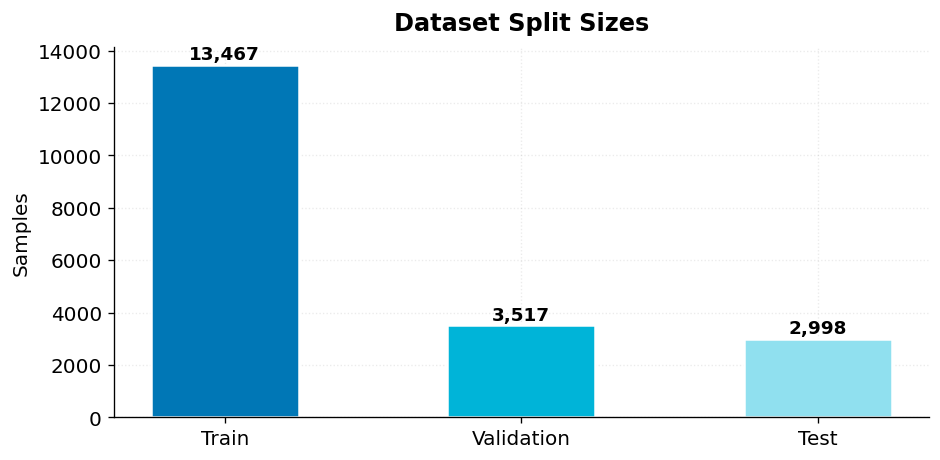

In [11]:
# Visualise split proportions
fig, ax = plt.subplots(figsize=(8, 4))

splits = ['Train', 'Validation', 'Test']
sizes = [len(train), len(val), len(test)]
colors = ['#0077B6', '#00B4D8', '#90E0EF']

bars = ax.bar(
    splits,
    sizes,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Annotate bar values
for bar, val_n in zip(bars, sizes):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{val_n:,}',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

ax.set_ylabel('Samples')
ax.set_title('Dataset Split Sizes', fontweight='bold', pad=10)

ax.set_axisbelow(True)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PREPROCESS_DIR / 'data_splits.png', bbox_inches='tight')
plt.show()

## Linguistic Feature Augmentation Across Splits

This section extends the dataset by incorporating linguistic features across all data splits. Counts of negation cues and intensifiers are computed and normalised by text length to produce comparable ratios.

The feature extraction process is applied consistently to training, validation, and test sets to maintain uniformity in representation. This ensures that all splits contain the same feature space for downstream modelling.

A combined summary is then used to examine average feature values across classes, providing a consolidated view of linguistic patterns in the dataset.

In [12]:
# Token-level count of signal words
def count_signal_words(text: str, signal_list: list) -> int:
    tokens = str(text).lower().split()
    return sum(t in signal_list for t in tokens)

# Linguistic features added to a dataset split
def add_ling_features(df_split: pd.DataFrame) -> pd.DataFrame:
    df_split = df_split.copy()\
    
    # Counts of negation and intensifier terms
    df_split['negation_count'] = df_split['text_clean'].apply(
        lambda x: count_signal_words(x, NEGATION_CUES)
    )

    df_split['intensifier_count'] = df_split['text_clean'].apply(
        lambda x: count_signal_words(x, INTENSIFIERS)
    )

    # Word count used for normalisation
    wc = df_split['text_clean'].str.split().str.len().clip(lower=1)

    # Ratio-based features
    df_split['neg_ratio'] = df_split['negation_count'] / wc
    df_split['intens_ratio'] = df_split['intensifier_count'] / wc

    return df_split

# Features applied across all splits
train = add_ling_features(train)
val = add_ling_features(val)
test = add_ling_features(test)

# Combined view for summary statistics
summary_df = pd.concat([train, val, test], ignore_index=True)

# Class-wise mean feature values
print('Linguistic features by class:')
print(
    summary_df.groupby('label')[
        ['neg_ratio', 'intens_ratio', 'intensifier_score']
    ]
    .mean()
    .round(4)
)

Linguistic features by class:
             neg_ratio  intens_ratio  intensifier_score
label                                                  
non-suicide     0.0136        0.0129             0.0129
suicide         0.0259        0.0139             0.0139


## Saving Processed Dataset

This step consolidates the training, validation, and test splits into a single dataset by adding a split identifier for each subset. This unified format simplifies data loading in later stages, as all required information is stored in one file while still preserving split boundaries.

The combined dataset is then saved to disk, ensuring that preprocessing does not need to be repeated and enabling efficient reuse across experiments.

In [13]:
# Add split identifiers
train['split'] = 'train'
val['split'] = 'val'
test['split'] = 'test'

# Combine all splits into a single dataset
processed = pd.concat([train, val, test]).reset_index(drop=True)

# Save processed dataset
processed.to_csv(LABELLED_DATASET, index=False)

# Verify columns and preview data
print(f'Columns: {processed.columns.tolist()}')
processed.head()

Columns: ['text', 'label', 'text_clean', 'text_neg_tagged', 'intensifier_score', 'label_id', 'negation_count', 'intensifier_count', 'neg_ratio', 'intens_ratio', 'split']


,text,label,text_clean,text_neg_tagged,intensifier_score,label_id,negation_count,intensifier_count,neg_ratio,intens_ratio,split
0,Loneliness Getting WorseYesterday night was th...,suicide,loneliness getting worseyesterday night was th...,loneliness getting worseyesterday night was th...,0.008889,1,5,2,0.022222,0.008889,train
1,Why do I feel like the only lonely person?It s...,suicide,why do i feel like the only lonely person?it s...,why do i feel like the only lonely person?it s...,0.000000,1,0,0,0.000000,0.000000,train
2,Am I the only one enjoying cyberpunk? I haven’...,non-suicide,am i the only one enjoying cyberpunk? i haven ...,am i the only one enjoying cyberpunk? i haven ...,0.031250,0,0,1,0.000000,0.031250,train
3,I've lost all interest in being.I have survive...,suicide,i've lost all interest in being.i have survive...,i've lost all interest in being.i have survive...,0.010135,1,9,3,0.030405,0.010135,train
4,I am getting so close to committing suicide an...,non-suicide,i am getting so close to committing suicide an...,i am getting so close to committing suicide an...,0.010204,0,3,1,0.030612,0.010204,train
